**###               ANÁLISIS COMERCIAL QNT - REBANCARIZACIÓN            ###**

---
---

*Primeros paso para el inicio del caso de estudio:*

**1.Estadistica Descriptiva**

In [146]:
#pip install pandas


In [147]:
#pip install numpy

In [148]:
#pip install ipykernel

In [149]:
#pip install matplotlib

In [150]:
#pip install seaborn

In [151]:
###LIBRERIAS BASICAS A USAR ###
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')

In [152]:
RUTA = "C:/Users/paola/Documents/ESTEBAN/Prueba QNT/"

ARCHIVOS = {
    "ventas"    : RUTA + "Base 1  Base Histórico De Ventas ",
    "gestion_24": RUTA + "Base 2.1 Base histórico de Gestión 2024.csv",
    "gestion_25": RUTA + "Base 2.2 Base histórico de Gestión 2025.csv",
    "vendedores": RUTA + "Base 3 Base de vendedores.csv",
}

In [153]:
# --- Configuración visual global ---
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9
})


In [154]:

# --- Rutas de los archivos ---



# =============================================================================
# UNION_DATOS
# =============================================================================
print("=" * 60)
print("RESUMEN_DATA")
print("=" * 60)

df_ventas= pd.read_csv("C:/Users/paola/Documents/ESTEBAN/Prueba QNT/Base 1  Base Histórico De Ventas .csv",encoding="utf-8")
df_gest_24= pd.read_csv("C:/Users/paola/Documents/ESTEBAN/Prueba QNT/Base 2.1  Base histórico de Gestión 2024  .csv", encoding="utf-8")
df_gest_25= pd.read_csv("C:/Users/paola/Documents/ESTEBAN/Prueba QNT/Base 2.2  Base histórico de Gestión 2025 .csv", encoding="utf-8")
df_vendedores = pd.read_csv("C:/Users/paola/Documents/ESTEBAN/Prueba QNT/Base 3  Base de vendedores.csv", encoding="utf-8")

# Unir los dos años de gestión
df_gestion = pd.concat([df_gest_24, df_gest_25], ignore_index=True)

print(f"      Ventas     : {df_ventas.shape[0]:,} filas   | {df_ventas.shape[1]} columnas")
print(f"  Gestión 2024   : {df_gest_24.shape[0]:,} filas    | {df_gest_24.shape[1]} columnas")
print(f"  Gestión 2025   : {df_gest_25.shape[0]:,} filas    | {df_gest_25.shape[1]} columnas")
print(f"  Gestión total  : {df_gestion.shape[0]:,} filas    | {df_gestion.shape[1]} columnas")
print(f"    Vendedores   : {df_vendedores.shape[0]:,} filas     | {df_vendedores.shape[1]} columnas")



# LIMPIEZA Y VALIDACIÓN
# =============================================================================
print("\n" + "=" * 60)
print("LIMPIEZA Y VALIDACIÓN")
print("=" * 60)

# --- 2.1 BASE VENTAS ---
print("\n[Base Ventas]")

# Tipos de datos
df_ventas['Mes'] = pd.to_datetime(df_ventas['Mes'], format='%Y-%m')
df_ventas['valor_capital__c']   = pd.to_numeric(df_ventas['valor_capital__c'],   errors='coerce')
df_ventas['Vr_Cuota_Mensual__c'] = pd.to_numeric(df_ventas['Vr_Cuota_Mensual__c'], errors='coerce')
df_ventas['Vr_Total_Acuerdo__c'] = pd.to_numeric(df_ventas['Vr_Total_Acuerdo__c'], errors='coerce')

# Nulos relevantes
nulos_ventas = df_ventas.isnull().sum()
print("  Nulos por columna:")
print(nulos_ventas[nulos_ventas > 0].to_string())
# NOTA: id_acuerdo_pago nulo = no hubo venta. Es correcto por diseño.

# Duplicados
dups_ventas = df_ventas.duplicated(subset=['Contacto__c', 'Oportunidad_Producto__c', 'Mes']).sum()
if dups_ventas > 0:
    print(f"\n  ⚠️  ALERTA: {dups_ventas} duplicados encontrados (cliente+producto+mes).")
    print("  → Conservando el registro más reciente por fecha de mes.")
    df_ventas = (df_ventas
                 .sort_values('Mes', ascending=False)
                 .drop_duplicates(subset=['Contacto__c', 'Oportunidad_Producto__c', 'Mes'])
                 .sort_values('Mes'))
else:
    print(f"  ✅ Sin duplicados en Base Ventas.")

RESUMEN_DATA
      Ventas     : 199,796 filas   | 7 columnas
  Gestión 2024   : 20,000 filas    | 7 columnas
  Gestión 2025   : 20,000 filas    | 7 columnas
  Gestión total  : 40,000 filas    | 7 columnas
    Vendedores   : 2,626 filas     | 2 columnas

LIMPIEZA Y VALIDACIÓN

[Base Ventas]
  Nulos por columna:
id_acuerdo_pago    188306
  ✅ Sin duplicados en Base Ventas.


In [155]:
print("\n[Base Gestión]")

df_gestion['Fecha_Gestion__c'] = pd.to_datetime(df_gestion['Fecha_Gestion__c'], errors='coerce', utc=True)
df_gestion['Fecha_Gestion__c'] = df_gestion['Fecha_Gestion__c'].dt.tz_localize(None)

# Limpieza de texto en categóricas
for col in ['Resultado_Principal__c', 'Resultado_Detalle__c', 'Explicacion__c']:
    df_gestion[col] = df_gestion[col].astype(str).str.strip()

dups_gest = df_gestion.duplicated(subset=['Contacto__c', 'Fecha_Gestion__c', 'User_RBK__c']).sum()
if dups_gest > 0:
    print(f"  ⚠️  ALERTA: {dups_gest} duplicados encontrado en la base gestión. se  decide eliminar.")
    df_gestion = df_gestion.drop_duplicates(subset=['Contacto__c', 'Fecha_Gestion__c', 'User_RBK__c'])
else:
    print(f"  ✅ Sin duplicados en Base Gestión.")

# --- 2.3 BASE VENDEDORES ---
print("\n[Base Vendedores]")
df_vendedores['CreatedDate'] = pd.to_datetime(df_vendedores['CreatedDate'], errors='coerce', utc=True)
df_vendedores['CreatedDate']  = df_vendedores['CreatedDate'].dt.tz_localize(None)
dups_vend = df_vendedores.duplicated(subset=['User_RBK__c']).sum()
if dups_vend > 0:
    print(f"  ⚠️  ALERTA: {dups_vend} vendedores duplicados. Se conserva el primero (más antiguo).")
    df_vendedores = df_vendedores.sort_values('CreatedDate').drop_duplicates(subset=['User_RBK__c'], keep='first')
else:
    print(f"  ✅ Sin duplicados en Base Vendedores.")


[Base Gestión]
  ⚠️  ALERTA: 587 duplicados encontrado en la base gestión. se  decide eliminar.

[Base Vendedores]
  ✅ Sin duplicados en Base Vendedores.


*---BASES_UNION---*

In [156]:

print("Estado_Bases")
# ---Feature engineering: ventas ---

# Flag de venta: Variable para categorizar la venta:1 si existe id_acuerdo_pago, 0 si no
df_ventas['flag_venta'] = df_ventas['id_acuerdo_pago'].notna().astype(int)

# Mes como texto para joins posteriores
df_ventas['mes_str'] = df_ventas['Mes'].dt.strftime('%Y-%m')

# ---Feature engineering: gestión ---

# Mes de gestión
df_gestion['mes_gestion'] = df_gestion['Fecha_Gestion__c'].dt.strftime('%Y-%m')

# Número de contactos por cliente (total histórico)
n_contactos = (df_gestion.groupby('Contacto__c').size().reset_index(name='n_gestiones'))

# Último resultado de gestión por cliente
ultimo_resultado = (df_gestion.sort_values('Fecha_Gestion__c').groupby('Contacto__c')
                    .agg(
                        ultimo_resultado_principal=('Resultado_Principal__c', 'last'),
                        ultimo_resultado_detalle=('Resultado_Detalle__c', 'last'),
                        ultima_explicacion=('Explicacion__c', 'last'),
                        fecha_ultima_gestion=('Fecha_Gestion__c', 'last'),
                        fecha_primera_gestion=('Fecha_Gestion__c', 'first'),
                        vendedor_ultimo=('User_RBK__c', 'last')).reset_index())

# Tiempo entre primer y último contacto (días)
ultimo_resultado['dias_entre_contactos'] = ((ultimo_resultado['fecha_ultima_gestion'] - ultimo_resultado['fecha_primera_gestion']).dt.days)

# ---Antigüedad del vendedor ---
fecha_ref = pd.Timestamp('2025-07-31')  # Fecha de cierre del análisis
df_vendedores['antiguedad_dias'] = (fecha_ref - df_vendedores['CreatedDate']).dt.days
df_vendedores['antiguedad_anios'] = (df_vendedores['antiguedad_dias'] / 365).round(1)

# --- JOIN MAESTRO ---
# Ventas + features de gestión
df_master = (df_ventas.merge(n_contactos,    on='Contacto__c', how='left').merge(ultimo_resultado, on='Contacto__c', how='left').merge(df_vendedores,  left_on='vendedor_ultimo', right_on='User_RBK__c', how='left'))


#######################################################################################################################################################
print(f"  Dataset maestro: {df_master.shape[0]:,} filas | {df_master.shape[1]} columnas")
print(f"  Clientes con historial de gestión: {df_master['n_gestiones'].notna().sum():,} ({df_master['n_gestiones'].notna().mean()*100:.1f}%)")




Estado_Bases
  Dataset maestro: 199,796 filas | 21 columnas
  Clientes con historial de gestión: 117,107 (58.6%)


In [157]:
# =============================================================================
#               ANÁLISIS EXPLORATORIO 
# =============================================================================
print("\n" + "=" * 60)
print("                 ANÁLISIS EXPLORATORIO           ")
print("=" * 60)

# --- 4.1 Resumen general ---
total_registros = len(df_ventas)
total_ventas    = df_ventas['flag_venta'].sum()
tasa_global     = total_ventas / total_registros * 100

print(f"\n  Total clientes/productos en portafolio : {total_registros:,}")
print(f"  Total acuerdos de pago cerrados        : {total_ventas:,}")
print(f"  Tasa de conversión global              : {tasa_global:.2f}%")
print(f"  Valor capital promedio                 : ${df_ventas['valor_capital__c'].mean():,.0f}")
print(f"  Valor acuerdo promedio (ventas)        : ${df_ventas[df_ventas['flag_venta']==1]['Vr_Total_Acuerdo__c'].mean():,.0f}")

# --- 4.2 Ventas por mes ---
ventas_mes = (df_ventas.groupby('mes_str').agg(total=('flag_venta','count'), ventas=('flag_venta','sum')).assign(tasa_conversion=lambda x: (x['ventas']/x['total']*100).round(2)).reset_index())

print("\n            Ventas mes a mes:")
print(ventas_mes.to_string(index=False))




                 ANÁLISIS EXPLORATORIO           

  Total clientes/productos en portafolio : 199,796
  Total acuerdos de pago cerrados        : 11,490
  Tasa de conversión global              : 5.75%
  Valor capital promedio                 : $5,427,757
  Valor acuerdo promedio (ventas)        : $1,941,363

            Ventas mes a mes:
mes_str  total  ventas  tasa_conversion
2024-06  19456    1296             6.66
2024-07  20872    1162             5.57
2024-08  20052    1144             5.71
2024-09  20219    1131             5.59
2024-10  14795    1092             7.38
2024-11  16170     916             5.66
2024-12  12428     917             7.38
2025-01  12075     676             5.60
2025-02  10322     553             5.36
2025-03   8432     439             5.21
2025-04  10657     622             5.84
2025-05  12086     622             5.15
2025-06  11823     572             4.84
2025-07  10409     348             3.34


**VISUALIZACIONES**         

---Acuerdos VS Tasa de conversion---

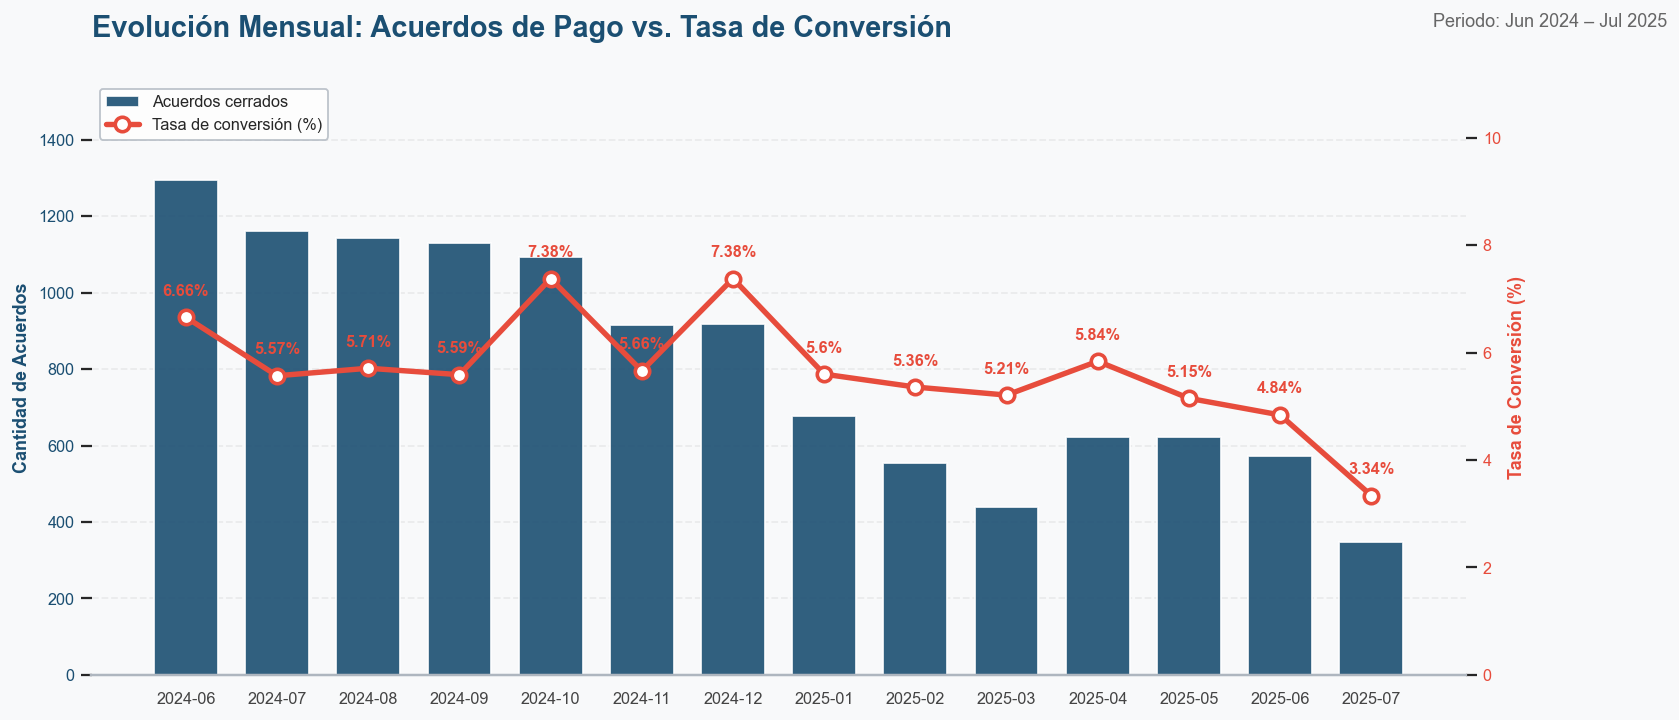

Evolucion_ventas.png


In [158]:
### PALETA DE COLORES ###
colores = {
    'principal' : '#1B4F72',
    'acento'    : '#E74C3C',
    'exito'     : '#1E8449',
    'neutro'    : '#AEB6BF',
    'fondo'     : '#F8F9FA',
}

# Configuración de estilo general de Seaborn para un look limpio
sns.set_style("white")

### GRÁFICO: Evolución de ventas y tasa de conversión mensual ###
fig, ax1 = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(colores['fondo'])
ax1.set_facecolor(colores['fondo'])

x = range(len(ventas_mes))

# 1. BARRAS (Ventas/Acuerdos)
bars = ax1.bar(x, ventas_mes['ventas'], color=colores['principal'],
               alpha=0.9, label='Acuerdos cerrados', zorder=2, width=0.7)

ax1.set_ylabel('Cantidad de Acuerdos', color=colores['principal'], fontweight='bold', fontsize=10)
ax1.tick_params(axis='y', labelcolor=colores['principal'])
ax1.set_xticks(x)
ax1.set_xticklabels(ventas_mes['mes_str'], rotation=0, ha='center', color='#444444') # Rotación 0 para mejor lectura si el espacio lo permite

# Ajustar límites para dar aire arriba
ax1.set_ylim(0, ventas_mes['ventas'].max() * 1.2)

# 2. LÍNEA (Tasa de conversión) - Eje secundario
ax2 = ax1.twinx()
ax2.plot(x, ventas_mes['tasa_conversion'], color=colores['acento'],
         marker='o', linewidth=3, markersize=8, label='Tasa de conversión (%)', 
         zorder=4, markerfacecolor='white', markeredgewidth=2)

ax2.set_ylabel('Tasa de Conversión (%)', color=colores['acento'], fontweight='bold', fontsize=10)
ax2.tick_params(axis='y', labelcolor=colores['acento'])
ax2.set_ylim(0, ventas_mes['tasa_conversion'].max() * 1.5)

# 3. ANOTACIONES ESTILIZADAS
for i, row in ventas_mes.iterrows():
    ax2.annotate(f"{row['tasa_conversion']}%",
                 xy=(i, row['tasa_conversion']),
                 xytext=(0, 12), textcoords='offset points',
                 ha='center', fontsize=9, fontweight='bold', 
                 color=colores['acento'])

# 4. LIMPIEZA DE BORDES (Spines)
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color(colores['neutro'])

# 5. CUADRÍCULA Y LEYENDA
ax1.grid(axis='y', linestyle='--', alpha=0.3, zorder=1)

# Leyenda unificada y elegante
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', 
           frameon=True, facecolor='white', edgecolor=colores['neutro'], fontsize=9)

# TÍTULO PROFESIONAL
plt.title('Evolución Mensual: Acuerdos de Pago vs. Tasa de Conversión\n', 
          fontsize=16, fontweight='bold', color=colores['principal'], loc='left')
plt.suptitle('Periodo: Jun 2024 – Jul 2025', fontsize=10, color='#666666', x=0.925, y=0.92, ha='left')

plt.tight_layout()

# GUARDAR
plt.savefig(RUTA + "01_evolucion_ventas_pro.png", dpi=300, bbox_inches='tight')
plt.show()

print("Evolucion_ventas.png")

---Detalle de flujo---

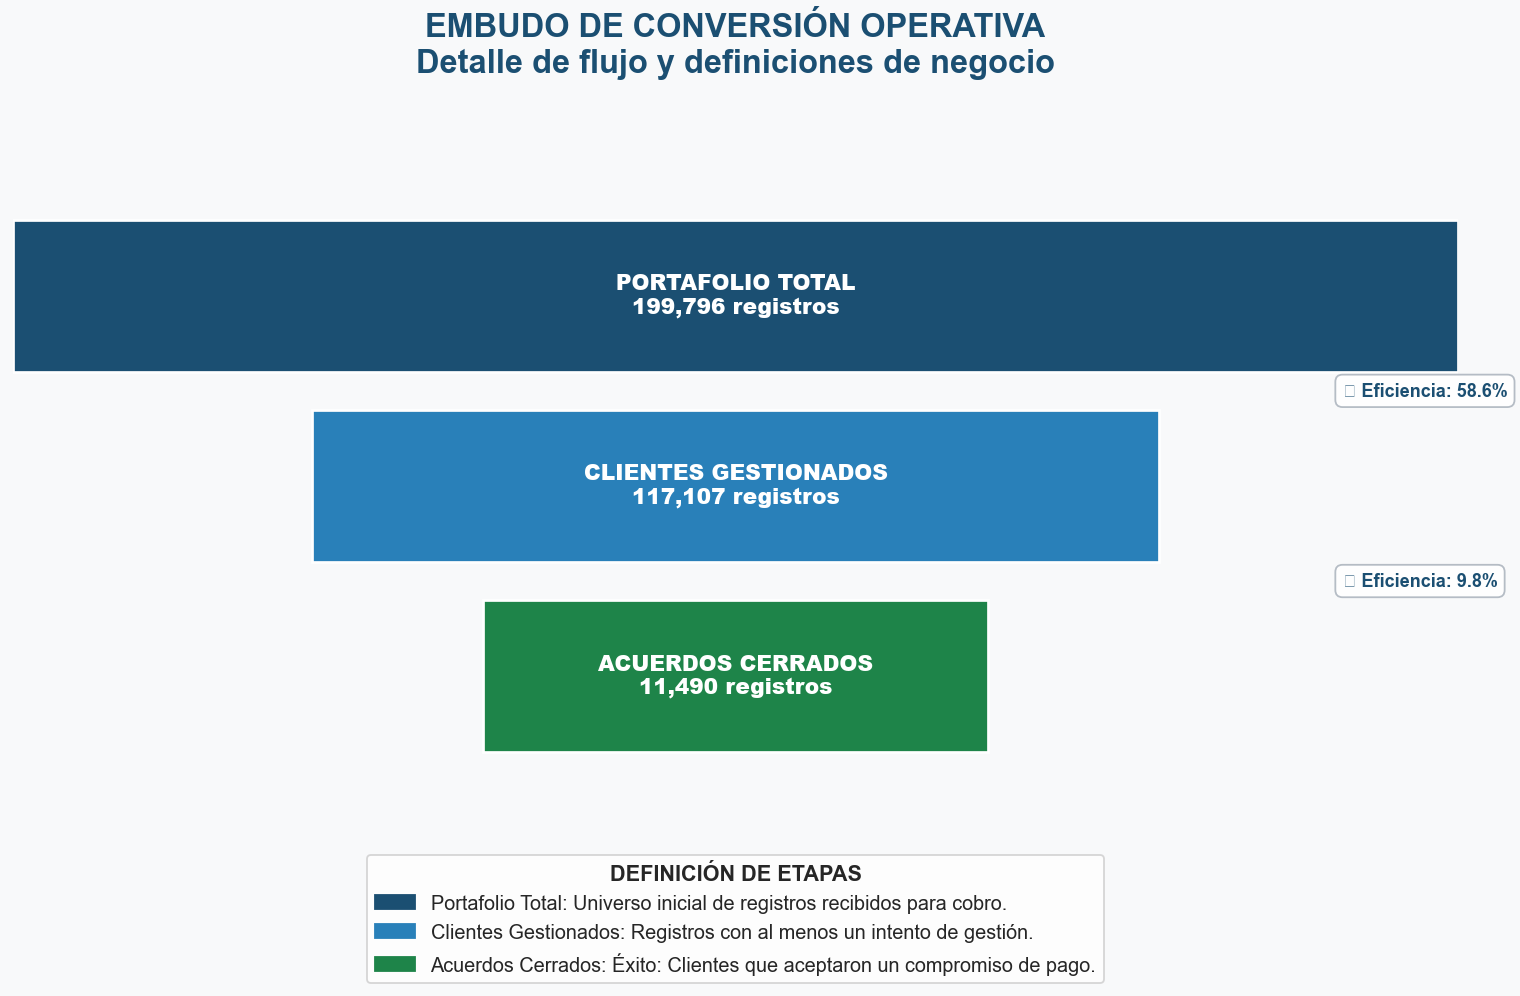

funnel_final.png


In [159]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- CONFIGURACIÓN DE DATOS ---
etapas_info = {
    'Portafolio Total': 'Universo inicial de registros recibidos para cobro.',
    'Clientes Gestionados': 'Registros con al menos un intento de gestión.',
    'Acuerdos Cerrados': 'Éxito: Clientes que aceptaron un compromiso de pago.'
}

etapas = list(etapas_info.keys())
valores = [total_registros, df_master['n_gestiones'].notna().sum(), total_ventas]
colores_etapas = [colores['principal'], '#2980B9', colores['exito']]

# --- CREACIÓN DE LA FIGURA ---
fig, ax = plt.subplots(figsize=(12, 9)) 
fig.patch.set_facecolor(colores['fondo'])
ax.set_facecolor(colores['fondo'])

max_val = max(valores)
y_pos = [2.5, 1.5, 0.5] # Espaciado vertical entre barras

# --- AJUSTE DE ANCHOS (Para que la barra verde sea grande) ---
anchos_visuales = []
for v in valores:
    ancho_real = v / max_val
    ancho_ajustado = max(ancho_real, 0.35) # Ancho mínimo del 35% para legibilidad
    anchos_visuales.append(ancho_ajustado)

izquierdas = [(1 - a) / 2 for a in anchos_visuales]

# --- DIBUJO DE BARRAS ---
for i in range(len(valores)):
    # Dibujar la barra
    ax.barh(y_pos[i], anchos_visuales[i], left=izquierdas[i], 
            color=colores_etapas[i], height=0.8, edgecolor='white', linewidth=1.5)
    
    # Texto: SIEMPRE BLANCO y centrado
    ax.text(0.5, y_pos[i], f"{etapas[i].upper()}\n{valores[i]:,} registros", 
            ha='center', va='center', color='white', 
            fontweight='black', fontsize=12)

# --- INDICADORES DE EFICIENCIA (Cálculo dinámico) ---
for i in range(len(valores) - 1):
    conv = (valores[i+1] / valores[i]) * 100
    ax.text(0.92, y_pos[i] - 0.5, f"⬇ Eficiencia: {conv:.1f}%", 
            ha='left', va='center', fontweight='bold', color=colores['principal'], fontsize=10,
            bbox=dict(facecolor='white', alpha=0.9, edgecolor=colores['neutro'], boxstyle='round,pad=0.4'))

# --- LEYENDA TÉCNICA (Ubicación interna) ---
leyenda_elementos = [mpatches.Patch(color=colores_etapas[i], label=f"{etapas[i]}: {etapas_info[etapas[i]]}") 
                     for i in range(len(etapas))]

leg = ax.legend(handles=leyenda_elementos, loc='lower center', 
                bbox_to_anchor=(0.5, -0.18), 
                ncol=1, frameon=True, fontsize=11, title="DEFINICIÓN DE ETAPAS")
plt.setp(leg.get_title(), fontweight='bold')

# --- TÍTULO Y LIMPIEZA DE EJES ---
ax.set_title('EMBUDO DE CONVERSIÓN OPERATIVA\nDetalle de flujo y definiciones de negocio', 
             fontsize=18, fontweight='bold', color=colores['principal'], pad=50)

ax.set_xlim(0, 1)
ax.set_ylim(-0.5, 3.2)
ax.axis('off')

# --- GUARDADO Y VISUALIZACIÓN ---
plt.tight_layout(rect=[0, 0.05, 1, 0.95]) 
plt.savefig(RUTA + "02_funnel_final_perfecto.png", dpi=300, bbox_inches='tight')
plt.show()

print("funnel_final.png")

*---Motivos_no_aceptacion---*

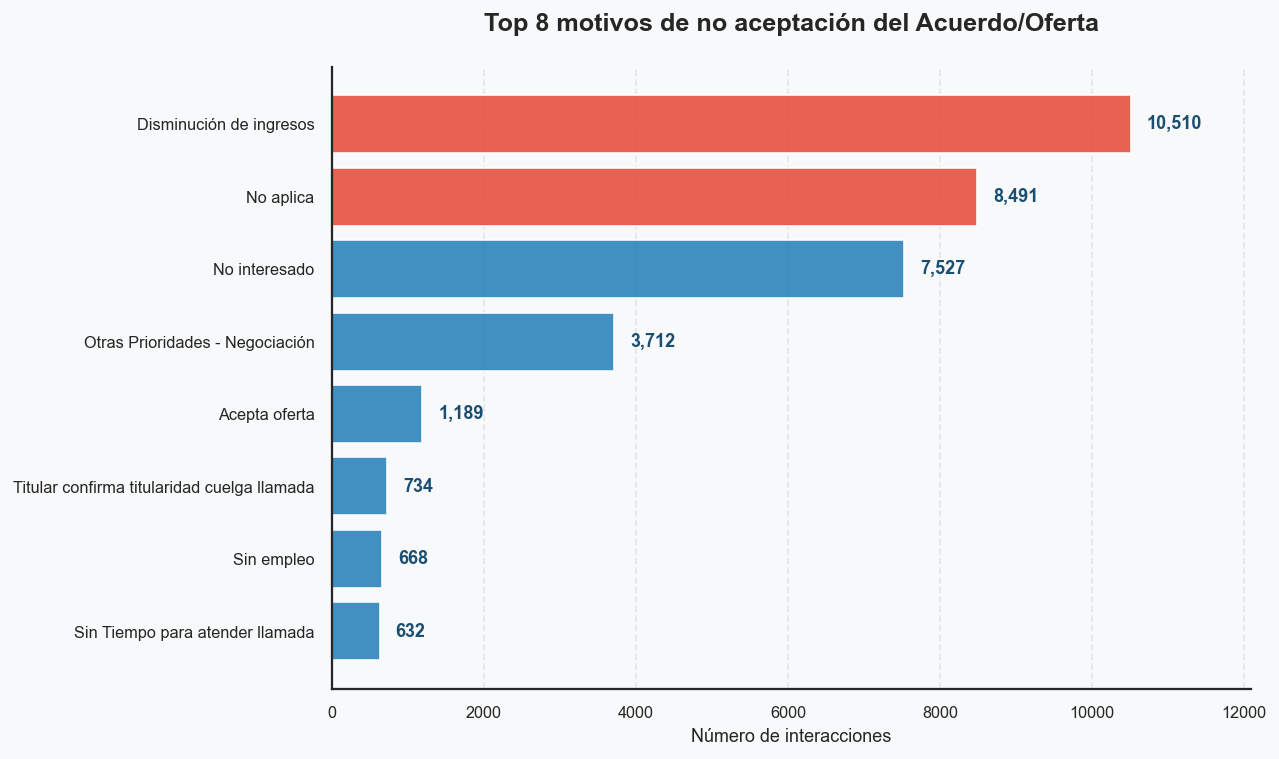

 Motivos_no_aceptacion.png


In [160]:
# --- GRÁFICO 3: Motivos de no aceptación ---
no_acepta = df_gestion[
    df_gestion['Resultado_Principal__c'].isin(['Localizado sin acuerdo', 'Titular cuelga llamada'])
]
motivos = (no_acepta['Explicacion__c']
           .value_counts()
           .head(8)
           .sort_values())

fig, ax = plt.subplots(figsize=(10, 6)) # Un poco más de altura
fig.patch.set_facecolor(colores['fondo'])
ax.set_facecolor(colores['fondo'])

# Colores dinámicos: Las 2 más altas con color de acento
colores_barras = [colores['acento'] if i >= len(motivos)-2 else '#2980B9' for i in range(len(motivos))]

bars = ax.barh(motivos.index, motivos.values, color=colores_barras, alpha=0.88)

# Ajuste del límite X para que el texto no se salga (15% de espacio extra)
ax.set_xlim(0, motivos.max() * 1.15)

for bar, val in zip(bars, motivos.values):
    ax.text(val + (motivos.max()*0.02), bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10, fontweight='bold', color=colores['principal'])

ax.set_title('Top 8 motivos de no aceptación del Acuerdo/Oferta', fontweight='bold', pad=20, fontsize=14)
ax.set_xlabel('Número de interacciones', fontsize=10)

# Limpieza de bordes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(RUTA + "Motivos_no_aceptacion.png", dpi=300, bbox_inches='tight')
plt.show()
print(" Motivos_no_aceptacion.png")

***---Tasa de conversión por resultado de gestión---***

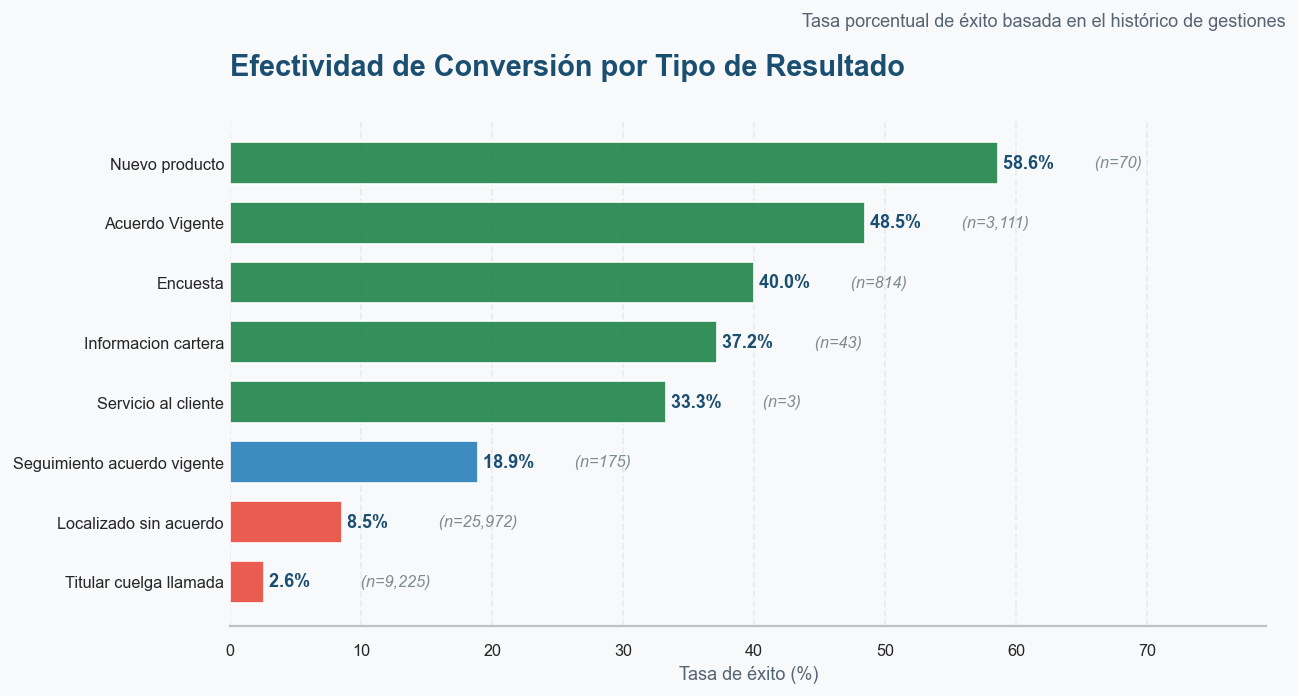

tasa_por_resultado_pro.png


In [161]:
# --- GRÁFICO 05: Tasa de conversión por resultado de gestión ---
# 1. Preparación de datos (Igual a tu lógica)
clientes_venta = df_ventas[['Contacto__c','flag_venta']].drop_duplicates('Contacto__c')
gest_con_venta = df_gestion.merge(clientes_venta, on='Contacto__c', how='inner')

tasa_por_resultado = (gest_con_venta
    .groupby('Resultado_Principal__c')
    .agg(total=('flag_venta','count'), ventas=('flag_venta','sum'))
    .assign(tasa=lambda x: (x['ventas']/x['total']*100).round(1))
    .sort_values('tasa', ascending=True)
    .reset_index())

# 2. Creación de la figura
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(colores['fondo'])
ax.set_facecolor(colores['fondo'])

# Lógica de colores profesional
colores_bars = [colores['exito'] if t > 30 else
                '#2980B9' if t > 10 else colores['acento']
                for t in tasa_por_resultado['tasa']]

# Dibujo de barras con altura ajustada para mayor elegancia
bars = ax.barh(tasa_por_resultado['Resultado_Principal__c'],
               tasa_por_resultado['tasa'], color=colores_bars, 
               alpha=0.9, height=0.7)

# 3. Etiquetas de datos estilizadas
for bar, (_, row) in zip(bars, tasa_por_resultado.iterrows()):
    # Ponemos la tasa en negrita y el tamaño de muestra en un tono más suave
    texto_etiqueta = f" {row['tasa']}% "
    texto_muestra = f" (n={row['total']:,})"
    
    # Tasa porcentual
    ax.text(row['tasa'], bar.get_y() + bar.get_height()/2,
            texto_etiqueta, va='center', ha='left', 
            fontsize=10, fontweight='bold', color=colores['principal'])
    
    # Tamaño de muestra desplazado
    ax.text(row['tasa'] + (tasa_por_resultado['tasa'].max()*0.12), 
            bar.get_y() + bar.get_height()/2,
            texto_muestra, va='center', ha='left', 
            fontsize=9, color='#7F8C8D', fontstyle='italic')

# 4. Ajustes de estética ejecutiva (Limpieza de bordes)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#BDC3C7')

# Título y Subtítulo
plt.title('Efectividad de Conversión por Tipo de Resultado\n', 
          loc='left', fontsize=16, fontweight='bold', color=colores['principal'])
plt.suptitle('Tasa porcentual de éxito basada en el histórico de gestiones', 
             x=0.625, y=0.92, ha='left', fontsize=10, color='#566573')

# Ejes y Cuadrícula
ax.set_xlabel('Tasa de éxito (%)', fontsize=10, color='#566573')
ax.set_xlim(0, tasa_por_resultado['tasa'].max() * 1.35) # Espacio para las etiquetas
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.tick_params(axis='y', length=0) # Quitar los ticks de las etiquetas Y

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(RUTA + "Tasa_por_resultado_pro.png", dpi=300, bbox_inches='tight')
plt.show()

print("tasa_por_resultado_pro.png")

***---Heatmap---***

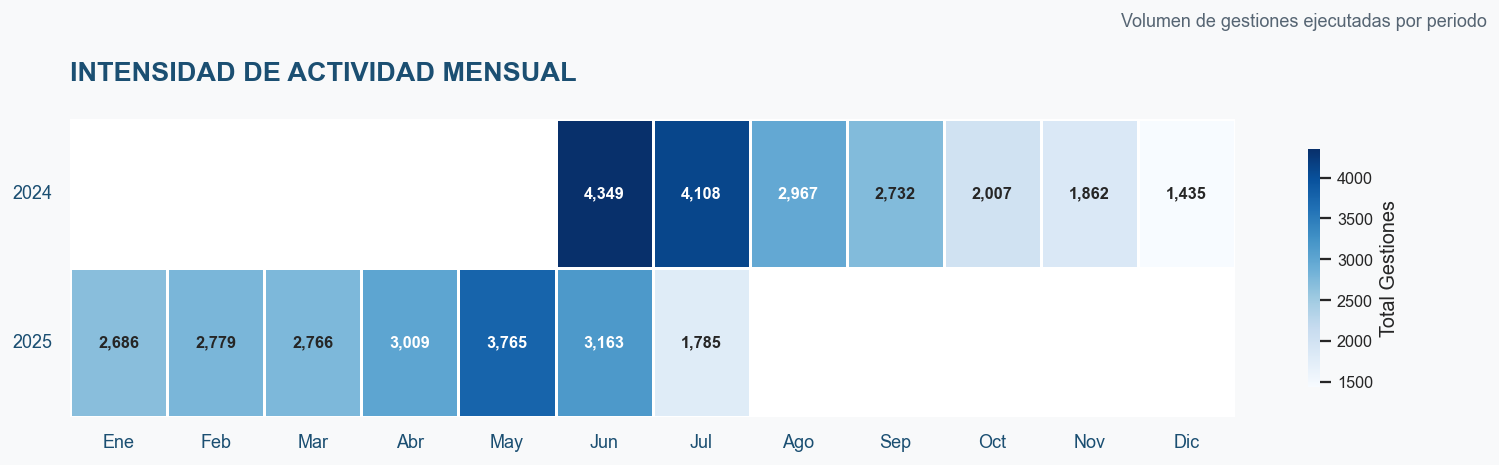

Heatmap_gestiones_pro.png


In [162]:
# --- Heatmap Profesional — Actividad de Gestión ---

# 1. Preparación de datos (Tu lógica es correcta)
df_gestion['mes_gest_dt'] = pd.to_datetime(df_gestion['mes_gestion'])
df_gestion['anio'] = df_gestion['mes_gest_dt'].dt.year
df_gestion['mes_num'] = df_gestion['mes_gest_dt'].dt.month
MESES_ES = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
            7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}

pivot = (df_gestion
         .groupby(['anio','mes_num'])
         .size()
         .reset_index(name='gestiones')
         .pivot(index='anio', columns='mes_num', values='gestiones')
         .rename(columns=MESES_ES))

# 2. Creación del gráfico
fig, ax = plt.subplots(figsize=(12, 4))
fig.patch.set_facecolor(colores['fondo'])

# Usamos una paleta de Azules (Blues) que es más profesional
# 'annot_kws' ajusta el tamaño de los números dentro de los cuadros
sns.heatmap(pivot, 
            annot=True, 
            fmt=',.0f', 
            cmap='Blues', 
            ax=ax,
            linewidths=1.5, 
            linecolor='white', 
            cbar_kws={'shrink': 0.8, 'label': 'Total Gestiones'},
            annot_kws={"size": 9, "weight": "semibold"})

# 3. Estética y Títulos
ax.set_title('INTENSIDAD DE ACTIVIDAD MENSUAL\n', 
             loc='left', fontsize=15, fontweight='bold', color=colores['principal'])
plt.suptitle('Volumen de gestiones ejecutadas por periodo', 
             x=0.725, y=0.92, ha='left', fontsize=10, color='#566573')

# Limpiar etiquetas de los ejes
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='both', which='major', labelsize=10, labelcolor=colores['principal'])

# Rotar los años para que se lean mejor si hay muchos
plt.yticks(rotation=0)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(RUTA + "06_heatmap_gestiones_pro.png", dpi=300, bbox_inches='tight')
plt.show()

print("Heatmap_gestiones_pro.png")


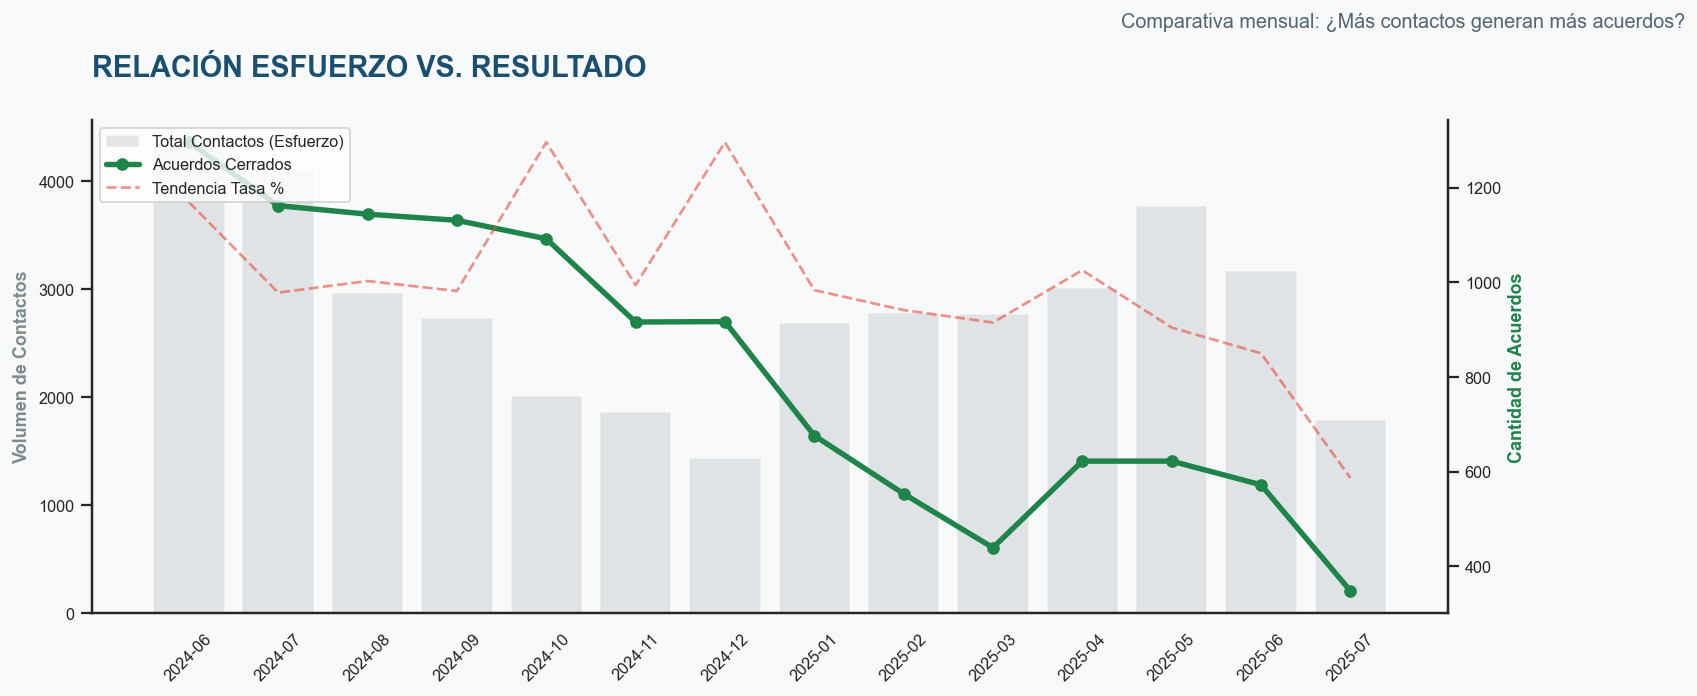

Tendencia_esfuerzo.png


In [163]:
# --- GRÁFICO 07: TENDENCIA DE ESFUERZO VS RESULTADO ---

# 1. Preparar datos de tendencia
gestiones_mes = df_gestion.groupby('mes_gestion').size().reset_index(name='contactos')
df_comparativo = ventas_mes.merge(gestiones_mes, left_on='mes_str', right_on='mes_gestion')

fig, ax1 = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(colores['fondo'])
ax1.set_facecolor(colores['fondo'])

# EJE 1: Barras para los Contactos (Esfuerzo)
color_esfuerzo = '#BDC3C7' # Gris neutro para no distraer
ax1.bar(df_comparativo['mes_str'], df_comparativo['contactos'], 
        color=color_esfuerzo, alpha=0.4, label='Total Contactos (Esfuerzo)')
ax1.set_ylabel('Volumen de Contactos', fontsize=10, fontweight='bold', color='#7F8C8D')

# EJE 2: Línea para los Acuerdos (Resultado)
ax2 = ax1.twinx() 
ax2.plot(df_comparativo['mes_str'], df_comparativo['ventas'], 
         color=colores['exito'], marker='o', linewidth=3, label='Acuerdos Cerrados')
ax2.set_ylabel('Cantidad de Acuerdos', fontsize=10, fontweight='bold', color=colores['exito'])

# EJE 3: Tasa de Conversión (Línea punteada)
ax2.plot(df_comparativo['mes_str'], df_comparativo['tasa_conversion'] * (df_comparativo['ventas'].max()/df_comparativo['tasa_conversion'].max()), 
         color=colores['acento'], linestyle='--', alpha=0.6, label='Tendencia Tasa %')

# Estética y Títulos
ax1.set_title('RELACIÓN ESFUERZO VS. RESULTADO\n', loc='left', fontsize=16, fontweight='bold', color=colores['principal'])
plt.suptitle('Comparativa mensual: ¿Más contactos generan más acuerdos?', 
             x=0.725, y=0.92, ha='left', fontsize=11, color='#566573')

# Ajustes de ejes
ax1.tick_params(axis='x', rotation=45)
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Leyenda combinada
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left', frameon=True, facecolor='white')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(RUTA + "Tendencia_esfuerzo.png", dpi=300, bbox_inches='tight')
plt.show()

print("Tendencia_esfuerzo.png")

In [164]:
# --- TENDENCIAS Y CORRELACIÓN ---

# A. Conversión Promedio Mensual
tasa_promedio_mensual = ventas_mes['tasa_conversion'].mean()

# B. Evaluación Acuerdos vs. Contactos (Esfuerzo vs Resultado)
# Agrupamos gestiones por mes para comparar con ventas_mes
gestiones_por_mes = (df_gestion
                     .groupby('mes_gestion')
                     .size()
                     .reset_index(name='total_contactos'))

# Unimos con nuestra tabla de ventas mensual
df_tendencia = ventas_mes.merge(gestiones_por_mes, left_on='mes_str', right_on='mes_gestion')

# C. Cálculo de Ratio de Esfuerzo (¿Cuántos contactos se necesitan para 1 acuerdo?)
df_tendencia['contactos_por_acuerdo'] = (df_tendencia['total_contactos'] / df_tendencia['ventas']).round(1)

print("\n" + "=" * 60)
print("   EVALUACIÓN DE TENDENCIAS Y ESFUERZO OPERATIVO")
print("=" * 60)
print(f"• Conversión Promedio Mensual: {tasa_promedio_mensual:.2f}%")
print(f"• Esfuerzo Promedio: {df_tendencia['contactos_por_acuerdo'].mean():.1f} contactos por cada acuerdo.")
print("-" * 60)

# Mostramos los últimos 5 meses para evaluar la caída mencionada
print("Últimos 5 meses de operación:")
print(df_tendencia[['mes_str', 'total_contactos', 'ventas', 'tasa_conversion', 'contactos_por_acuerdo']].tail(5))


   EVALUACIÓN DE TENDENCIAS Y ESFUERZO OPERATIVO
• Conversión Promedio Mensual: 5.66%
• Esfuerzo Promedio: 3.9 contactos por cada acuerdo.
------------------------------------------------------------
Últimos 5 meses de operación:
    mes_str  total_contactos  ventas  tasa_conversion  contactos_por_acuerdo
9   2025-03             2766     439             5.21                    6.3
10  2025-04             3009     622             5.84                    4.8
11  2025-05             3765     622             5.15                    6.1
12  2025-06             3163     572             4.84                    5.5
13  2025-07             1785     348             3.34                    5.1


In [165]:



# =============================================================================
# 7. RESUMEN EJECUTIVO EN CONSOLA
# =============================================================================
print("\n" + "*" * 60)
print("                  RESUMEN INSIGHTS      ")
print("*" * 60)

mejor_mes = ventas_mes.loc[ventas_mes['ventas'].idxmax()]
peor_mes  = ventas_mes.loc[ventas_mes['ventas'].idxmin()]
mejor_tasa = ventas_mes.loc[ventas_mes['tasa_conversion'].idxmax()]

print(f"""
   NEGOCIO
  ─────────────────────────────────────────────────────
  • Portafolio analizado    : {total_registros:,} registros (Jun 2024 – Jul 2025)
  • Acuerdos cerrados       : {total_ventas:,} ({tasa_global:.1f}% de conversión global)
  • Capital promedio deuda  : ${df_ventas['valor_capital__c'].mean()/1e6:.1f}M COP
  • Valor promedio acuerdo  : ${df_ventas[df_ventas['flag_venta']==1]['Vr_Total_Acuerdo__c'].mean()/1e6:.1f}M COP

   TENDENCIAS
  ─────────────────────────────────────────────────────
  • Mejor mes en acuerdos   : {mejor_mes['mes_str']} ({mejor_mes['ventas']:,} acuerdos)
  • Mejor tasa conversión   : {mejor_tasa['mes_str']} ({mejor_tasa['tasa_conversion']}%)
  • Tendencia 2025          : Portafolio en reducción y tasa de conversión cayendo
  • Jul 2025 (parcial)      : Solo 3.3% de conversión – señal de alerta

   MOTIVOS DE NO VENTA
  ─────────────────────────────────────────────────────
  • #1 Disminución de ingresos   (40.6% de no conversiones)
  • #2 No interesado             (29.0%)
  • #3 Otras prioridades         (14.2%)
  • #4 Sin empleo                ( 2.5%)
  • → Problema central: capacidad de pago, no falta de voluntad.

   LO QUE FUNCIONA
  ─────────────────────────────────────────────────────
  • Clientes con "Acuerdo Vigente" tienen la mayor tasa de conversión
  • Clientes con multiples contactos muestran mayor probabilidad de cierre
  • Deudas de capital más bajo se convierten más fácilmente

    OPORTUNIDADES
  ─────────────────────────────────────────────────────
  • Solo ~45% del portafolio tiene historial de gestión -- el 55% no ha sido contactado
  • El motivo #1 ("Disminución de ingresos") sugiere que las cuotas son altas
  • Hay espacio para flexibilizar la oferta y mejorar la segmentación
""")




************************************************************
                  RESUMEN INSIGHTS      
************************************************************

   NEGOCIO
  ─────────────────────────────────────────────────────
  • Portafolio analizado    : 199,796 registros (Jun 2024 – Jul 2025)
  • Acuerdos cerrados       : 11,490 (5.8% de conversión global)
  • Capital promedio deuda  : $5.4M COP
  • Valor promedio acuerdo  : $1.9M COP

   TENDENCIAS
  ─────────────────────────────────────────────────────
  • Mejor mes en acuerdos   : 2024-06 (1,296 acuerdos)
  • Mejor tasa conversión   : 2024-10 (7.38%)
  • Tendencia 2025          : Portafolio en reducción y tasa de conversión cayendo
  • Jul 2025 (parcial)      : Solo 3.3% de conversión – señal de alerta

   MOTIVOS DE NO VENTA
  ─────────────────────────────────────────────────────
  • #1 Disminución de ingresos   (40.6% de no conversiones)
  • #2 No interesado             (29.0%)
  • #3 Otras prioridades         (14.2%)
  • 

***POWER BI***

A partir de este punto se comienza con la creacion de un tablero sencillo que permita tener control a nivel de vendedor y tipificación, para encontrar estrategias Optimas de acuerdo al Core del negocio


In [166]:


#POWER BI


# Tabla 1: Ventas enriquecidas
pbi_ventas = df_master[['Mes', 'mes_str', 'Contacto__c', 'Oportunidad_Producto__c','valor_capital__c', 'flag_venta', 
                        'Vr_Cuota_Mensual__c', 'Vr_Total_Acuerdo__c','n_gestiones', 'ultimo_resultado_principal', 'ultimo_resultado_detalle',
                        'ultima_explicacion', 'dias_entre_contactos', 'antiguedad_anios']].copy()
pbi_ventas['Mes'] = pbi_ventas['Mes'].dt.strftime('%Y-%m-%d')
pbi_ventas.to_csv(RUTA + "PBI_01_ventas_enriquecidas.csv", index=False, encoding='utf-8-sig')
print(f" PBI_01_ventas_enriquecidas.csv    ({len(pbi_ventas):,} filas)")

# Tabla 2: Resumen mensual
pbi_mensual = ventas_mes.copy()
pbi_mensual.to_csv(RUTA + "PBI_02_resumen_mensual.csv", index=False, encoding='utf-8-sig')
print(f" PBI_02_resumen_mensual.csv        ({len(pbi_ventas):,} filas)")

# Tabla 3: Gestión limpia
pbi_gestion = df_gestion[[
    'Contacto__c', 'Fecha_Gestion__c', 'mes_gestion',
    'Resultado_Principal__c', 'Resultado_Detalle__c',
    'Explicacion__c', 'User_RBK__c'
]].copy()
pbi_gestion['Fecha_Gestion__c'] = pbi_gestion['Fecha_Gestion__c'].astype(str)
pbi_gestion.to_csv(RUTA + "PBI_03_gestion_limpia.csv", index=False, encoding='utf-8-sig')
print(f" PBI_03_gestion_limpia.csv         ({len(pbi_gestion):,} filas)")

# Tabla 4: Vendedores con antigüedad
pbi_vendedores = df_vendedores[['User_RBK__c','CreatedDate','antiguedad_dias','antiguedad_anios']].copy()
pbi_vendedores['CreatedDate'] = pbi_vendedores['CreatedDate'].astype(str)
pbi_vendedores.to_csv(RUTA + "PBI_04_vendedores.csv", index=False, encoding='utf-8-sig')
print(f" PBI_04_vendedores.csv             ({len(pbi_vendedores):,} filas)")


 PBI_01_ventas_enriquecidas.csv    (199,796 filas)
 PBI_02_resumen_mensual.csv        (199,796 filas)
 PBI_03_gestion_limpia.csv         (39,413 filas)
 PBI_04_vendedores.csv             (2,626 filas)
